In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import zipfile
import io
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

#DATOS VENTAS

In [ ]:
ventas = pd.read_csv("ventas.csv", encoding='latin1', delimiter=',')
ventas

<ipython-input-2-343d1d810e68>:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv("ventas.csv", encoding='latin1', delimiter=',')


Acortar datos para que coincidan las fechas con la pandemia

In [ ]:
ventas = ventas.drop(['Puc', 'Pmc', 'Pvp', 'ProveedorHabitual','Laboratorio'],axis=1)

ventas['FechaHora'] = pd.to_datetime(ventas['FechaHora'])

ventas = ventas[ventas['FechaHora'] <= '2022-03-28']

ventas = ventas.dropna(subset=['Descripcion'])

ventas['Cantidad'] = ventas['Cantidad'].apply(lambda x: max(x, 0))

In [ ]:
ventas

,IdVenta,FechaHora,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
1,1278614,2020-01-01 08:24:35.550,1,2.5,679426,ESPIDIFEN EFG 600 MG 20 SOBRES GRANULADO MENTA,2.0,2023-11-17,2026-06-30,23.0,ESP.ÃÃÃE.F.G
2,1278615,2020-01-01 08:29:43.410,1,5.18,698079,EUTIROX 112 MCG 100 COMPRIMIDOS,2.0,2023-11-13,2025-09-30,2.0,ESPECIALIDADES
3,1278615,2020-01-01 08:29:43.410,1,2.5,677381,ENALAPRIL CINFA 10 MG 56 COMPRIMIDOS,38.0,2023-08-25,2025-05-12,23.0,ESP.ÃÃÃE.F.G
4,1278615,2020-01-01 08:29:43.410,2,1.72,770065,ORFIDAL 1 MG 50 COMPR.,10.0,2023-11-20,2024-09-30,2.0,ESPECIALIDADES
5,1278616,2020-01-01 08:52:31.413,1,10.21,697876,AUGMENTINE 875/125 MG 30 COMPRIMIDOS,6.0,2023-11-20,2024-02-29,2.0,ESPECIALIDADES
...,...,...,...,...,...,...,...,...,...,...,...
753135,1584146,2022-03-27 21:42:24.953,1,7.95,357357,NECESER DENTAL LOL,0.0,2022-04-27,NaN,15.0,HIGIENE BUCAL
753136,1584147,2022-03-27 21:43:56.753,1,7.91,866103,CETRAXAL PLUS GOTAS OTICAS SOLUCION 10 ML,99.0,2023-08-10,2024-07-01,2.0,ESPECIALIDADES
753137,1584148,2022-03-27 21:46:22.053,2,4.04,653619,ESTILSONA 13.3 MG/ML GOTAS ORALES SUSPENSION 10,61.0,2023-10-23,2024-06-30,2.0,ESPECIALIDADES
753138,1584149,2022-03-27 21:53:01.700,1,3.76,997585,BACTROBAN 20 MG/G POMADA 15 G,2.0,2023-11-20,2025-06-30,2.0,ESPECIALIDADES


In [ ]:
print(ventas.describe())

            IdVenta                      FechaHora       Cantidad  \
count  7.123210e+05                         712321  712321.000000   
mean   1.434887e+06  2021-03-05 21:35:05.672023552       1.581902   
min    1.278614e+06     2020-01-01 08:24:35.550000       0.000000   
25%    1.358374e+06  2020-08-13 17:52:25.903000064       1.000000   
50%    1.437055e+06     2021-03-20 09:48:11.240000       1.000000   
75%    1.511662e+06  2021-10-05 18:53:49.830000128       1.000000   
max    1.584150e+06     2022-03-27 21:59:51.647000    1600.000000   
std    8.823413e+04                            NaN       6.291370   

            IdArticu    StockActual      IdFamilia  
count  712321.000000  712321.000000  696179.000000  
mean   498121.968238      26.903810      12.703216  
min        12.000000      -4.000000       1.000000  
25%    184834.000000       2.000000       2.000000  
50%    658247.000000       6.000000      13.000000  
75%    709818.000000      26.000000      23.000000  
max    

In [ ]:
ventas['FechaHora'] = pd.to_datetime(ventas['FechaHora'])
ventas.set_index('FechaHora', inplace=True)

ventas_diarias = ventas.resample('D')['Cantidad'].sum()

ventas_diarias = ventas_diarias.to_frame(name='VentasDiarias')


In [ ]:
ventas_diarias

,VentasDiarias
FechaHora,
2020-01-01,811
2020-01-02,1248
2020-01-03,855
2020-01-04,887
2020-01-05,904
...,...
2022-03-23,1284
2022-03-24,1436
2022-03-25,1768


In [ ]:
print(ventas_diarias.describe())

       VentasDiarias
count     817.000000
mean     1379.219094
std       602.323162
min       570.000000
25%       905.000000
50%      1306.000000
75%      1653.000000
max      5520.000000


#DATOS CASOS IB

In [ ]:
casos = pd.read_csv("evolucion_pandemia.csv", encoding='latin1')

casos_ib = casos[casos['provincia_iso'] == 'PM']

casos_ib['fecha'] = pd.to_datetime(casos_ib['fecha'])

casos_ib = casos_ib.groupby('fecha').sum()

casos_ib = casos_ib.drop(columns=['sexo', 'grupo_edad', 'provincia_iso'])



<ipython-input-9-2e87b5db2d12>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  casos_ib['fecha'] = pd.to_datetime(casos_ib['fecha'])


In [ ]:
if casos_ib.isnull().values.any():
    casos_ib.fillna(0, inplace=True)
else:
    print("No hay valores NaN en el DataFrame.")

No hay valores NaN en el DataFrame.


In [ ]:
casos_ib

,num_casos,num_hosp,num_uci,num_def
fecha,,,,
2020-01-01,0,0,0,0
2020-01-02,0,0,0,0
2020-01-03,0,0,0,0
2020-01-04,0,0,0,0
2020-01-05,0,0,0,0
...,...,...,...,...
2022-03-23,574,3,1,1
2022-03-24,470,2,0,0
2022-03-25,407,3,0,0


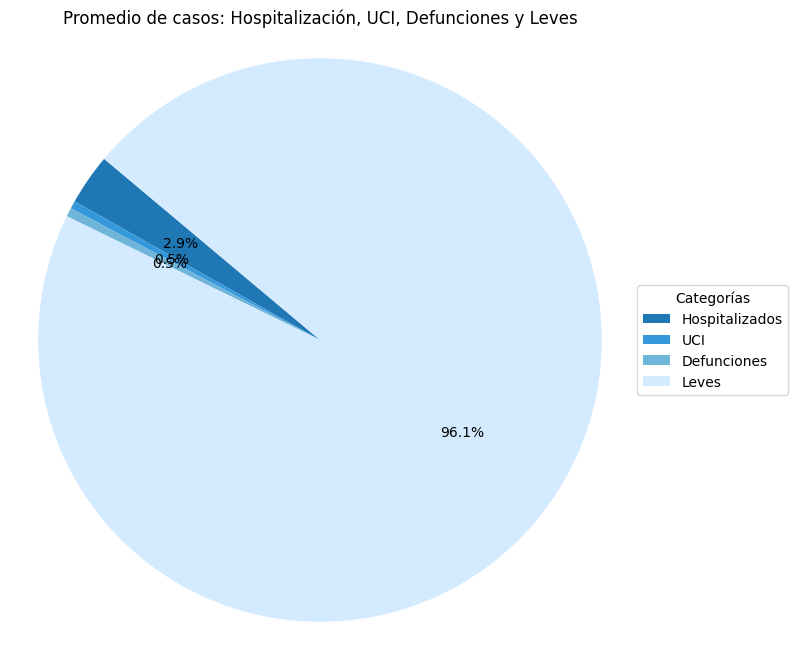

In [ ]:
promedios = [9.856793, 1.520196, 1.685435]
categorias = ['Hospitalizados', 'UCI', 'Defunciones']
total_casos = 337.080783

suma_categorias = sum(promedios)
leves = total_casos - suma_categorias

promedios.append(leves)
categorias.append('Leves')

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(promedios, colors=['#1f77b4', '#3498db', '#6fb4d9', '#d4eaff'], autopct='%1.1f%%', startangle=140)
plt.title('Promedio de casos: Hospitalización, UCI, Defunciones y Leves')
plt.axis('equal')

plt.legend(wedges, categorias, title="Categorías", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()


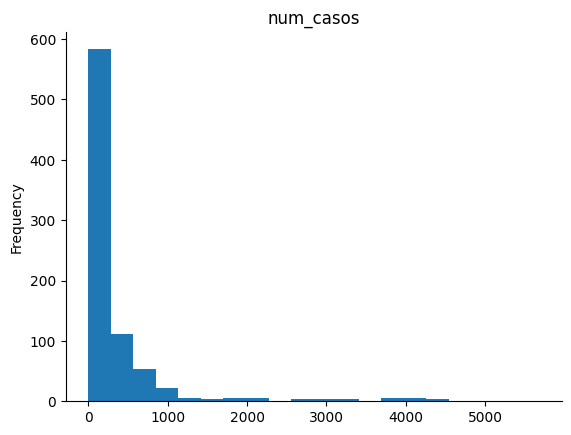

In [ ]:
casos_ib['num_casos'].plot(kind='hist', bins=20, title='num_casos')
plt.gca().spines[['top', 'right',]].set_visible(False)

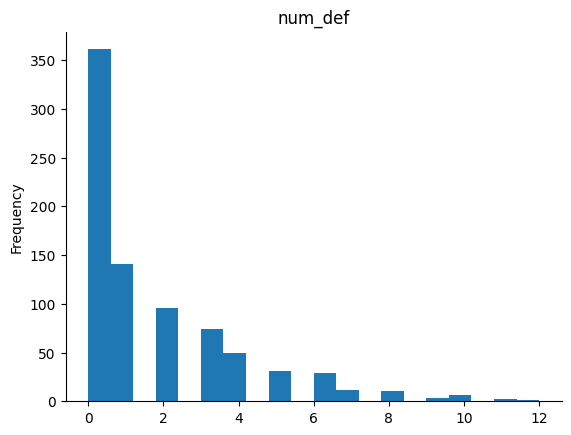

In [ ]:
casos_ib['num_def'].plot(kind='hist', bins=20, title='num_def')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
print(casos_ib.describe())

         num_casos    num_hosp     num_uci     num_def
count   817.000000  817.000000  817.000000  817.000000
mean    337.080783    9.856793    1.520196    1.685435
std     693.885660   11.092539    2.058554    2.216846
min       0.000000    0.000000    0.000000    0.000000
25%      30.000000    2.000000    0.000000    0.000000
50%      99.000000    6.000000    1.000000    1.000000
75%     338.000000   15.000000    2.000000    3.000000
max    5678.000000   69.000000   14.000000   12.000000


- El número total de registros de casos de COVID-19 es de 817.
- El número medio de casos diarios es de aproximadamente 337, con un mínimo de 0 y un máximo de 5678.
- El número medio de hospitalizaciones diarias es de aproximadamente 9.86, con un mínimo de 0 y un máximo de 69.
- El número medio de ingresos en unidades de cuidados intensivos (UCI) diarios es de aproximadamente 1.52, con un mínimo de 0 y un máximo de 14.
- El número medio de defunciones diarias es de aproximadamente 1.69, con un mínimo de 0 y un máximo de 12.

# DIVISION POR OLAS

In [ ]:
fechas_olas = [
    ('2020-02-27', '2020-05-31'),  # Ola 1 dia con primer casos registrados
    ('2020-06-01', '2020-11-30'),  # Ola 2
    ('2020-12-01', '2021-02-28'),  # Ola 3
    ('2021-03-01', '2021-05-31'),  # Ola 4
    ('2021-06-01', '2021-10-31'),  # Ola 5
    ('2021-11-01', '2022-03-27')   # Ola 6
]

ola1 = casos_ib.loc[fechas_olas[0][0]:fechas_olas[0][1]]
ola2 = casos_ib.loc[fechas_olas[1][0]:fechas_olas[1][1]]
ola3 = casos_ib.loc[fechas_olas[2][0]:fechas_olas[2][1]]
ola4 = casos_ib.loc[fechas_olas[3][0]:fechas_olas[3][1]]
ola5 = casos_ib.loc[fechas_olas[4][0]:fechas_olas[4][1]]
ola6 = casos_ib.loc[fechas_olas[5][0]:fechas_olas[5][1]]

print('Ola 1:')
print(ola1)
print()

print('Ola 2:')
print(ola2)
print()

print('Ola 3:')
print(ola3)
print()

print('Ola 4:')
print(ola4)
print()

print('Ola 5:')
print(ola5)
print()

print('Ola 6:')
print(ola6)
print()

Ola 1:
            num_casos  num_hosp  num_uci  num_def
fecha                                            
2020-02-27          2         1        0        0
2020-02-28          1         1        0        0
2020-02-29          0         0        0        0
2020-03-01          1         0        0        0
2020-03-02          1         1        0        0
...               ...       ...      ...      ...
2020-05-27          7         0        0        0
2020-05-28         10         0        0        0
2020-05-29          5         0        0        0
2020-05-30          0         0        0        0
2020-05-31          2         1        0        0

[95 rows x 4 columns]

Ola 2:
            num_casos  num_hosp  num_uci  num_def
fecha                                            
2020-06-01          4         0        0        0
2020-06-02          7         0        0        0
2020-06-03          4         1        0        0
2020-06-04          4         0        0        0
2020-06-05  

In [ ]:
recuento_olas = []

for i, df_ola in enumerate([ola1, ola2, ola3, ola4, ola5, ola6], start=1):
    recuento_casos = df_ola['num_casos'].sum()
    recuento_defunciones = df_ola['num_def'].sum()
    tasa_mortalidad = recuento_defunciones/recuento_casos
    recuento_olas.append({'Ola': i, 'Recuento_Casos': recuento_casos, 'Recuento_Defunciones': recuento_defunciones, 'Tasa mortalidad': tasa_mortalidad})

df_recuento_olas = pd.DataFrame(recuento_olas)

print(df_recuento_olas)


   Ola  Recuento_Casos  Recuento_Defunciones  Tasa mortalidad
0    1            2180                   226         0.103670
1    2           22721                   226         0.009947
2    3           31368                   359         0.011445
3    4            4154                    36         0.008666
4    5           41331                   170         0.004113
5    6          173640                   360         0.002073


#RELACION ENTRE LAS DOS BBDD

In [ ]:
total_articulos = ventas['IdArticu'].nunique()
total_articulos

13254

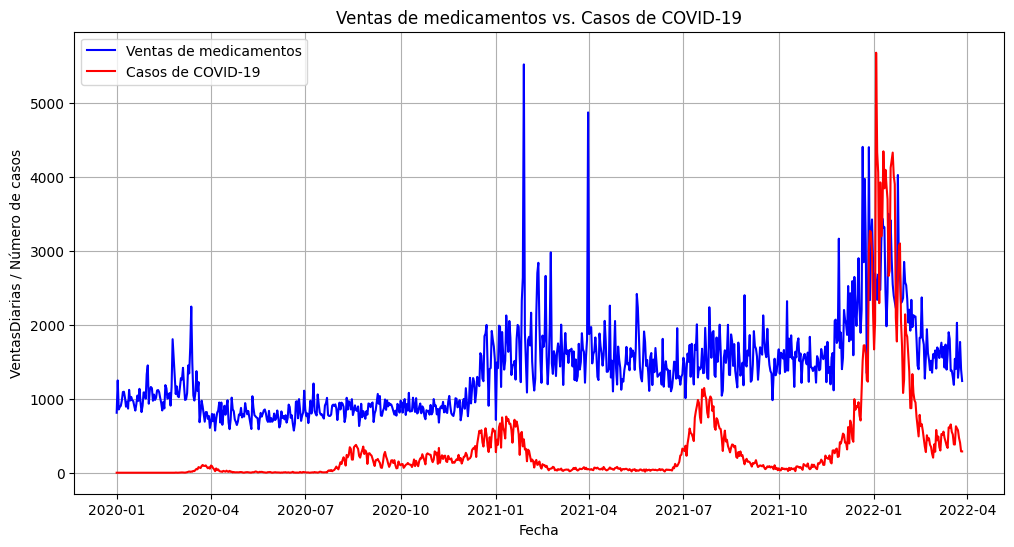

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ventas_diarias.index, ventas_diarias['VentasDiarias'], color='blue', label='Ventas de medicamentos')
plt.plot(casos_ib.index, casos_ib['num_casos'], color='red', label='Casos de COVID-19')
plt.title('Ventas de medicamentos vs. Casos de COVID-19')
plt.xlabel('Fecha')
plt.ylabel('VentasDiarias / Número de casos')
plt.legend()
plt.grid(True)
plt.show()

Coeficiente de correlación: 0.6020507796140123
Coeficiente de la regresión: 0.5226064605393325, Intercepto: 1203.058499142926


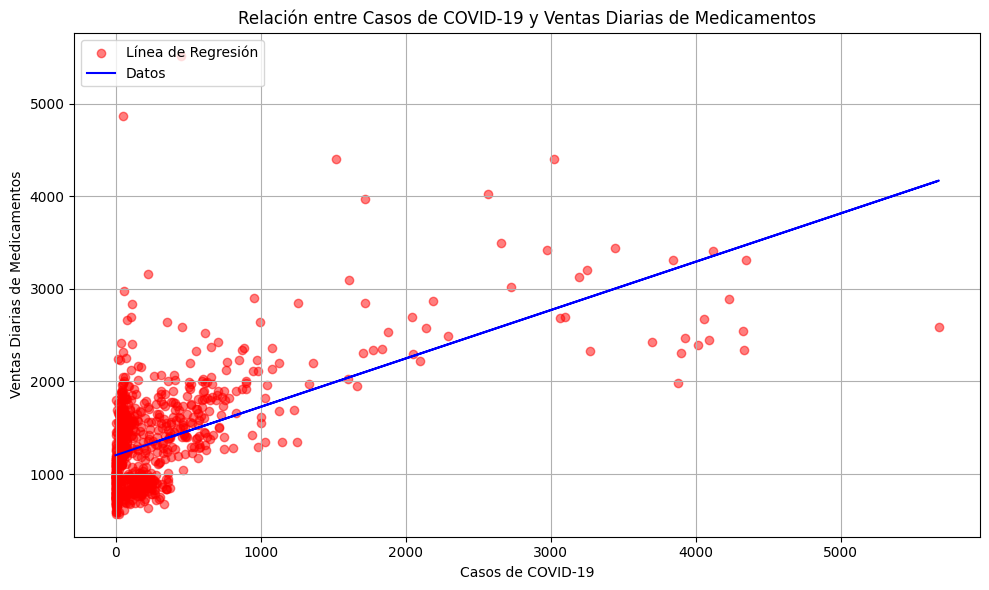

In [ ]:
corr, _ = pearsonr(casos_ib['num_casos'], ventas_diarias['VentasDiarias'])
print(f'Coeficiente de correlación: {corr}')

X = casos_ib['num_casos'].values.reshape(-1, 1)
y = ventas_diarias['VentasDiarias'].values
modelo = LinearRegression().fit(X, y)
print(f'Coeficiente de la regresión: {modelo.coef_[0]}, Intercepto: {modelo.intercept_}')

plt.figure(figsize=(10, 6))
plt.scatter(casos_ib['num_casos'], ventas_diarias['VentasDiarias'], color='red', alpha=0.5)
plt.plot(casos_ib['num_casos'], modelo.predict(X), color='blue')
plt.title('Relación entre Casos de COVID-19 y Ventas Diarias de Medicamentos')
plt.xlabel('Casos de COVID-19')
plt.ylabel('Ventas Diarias de Medicamentos')
plt.grid(True)
plt.legend(['Línea de Regresión', 'Datos'], loc='upper left')
plt.tight_layout()
plt.show()


El coeficiente de correlación de Pearson entre los casos de COVID-19 y las ventas diarias de medicamentos es aproximadamente 0.601, lo que indica una correlación moderada positiva entre estas dos variables.

Además, el coeficiente de la regresión lineal es aproximadamente 0.518, lo que significa que por cada aumento unitario en el número de casos de COVID-19, se espera un aumento de aproximadamente 0.518 unidades en las ventas diarias de medicamentos. El intercepto del modelo de regresión lineal es aproximadamente 1190.325, lo que representa el valor esperado de las ventas diarias de medicamentos cuando el número de casos de COVID-19 es cero (es decir, el valor inicial de las ventas diarias de medicamentos).

Estos resultados sugieren que existe una asociación positiva entre los casos de COVID-19 y las ventas diarias de medicamentos, y que el modelo de regresión lineal puede ser útil para predecir las ventas diarias de medicamentos basándose en el número de casos de COVID-19.

# ARTICULOS MAS VENDIDOS

<ipython-input-22-162e2ea6f345>:22: UserWarning: Glyph 138 (\x8a) missing from current font.
  plt.tight_layout()
<ipython-input-22-162e2ea6f345>:22: UserWarning: Glyph 155 (\x9b) missing from current font.
  plt.tight_layout()
<ipython-input-22-162e2ea6f345>:22: UserWarning: Glyph 132 (\x84) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 138 (\x8a) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 155 (\x9b) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 132 (\x84) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


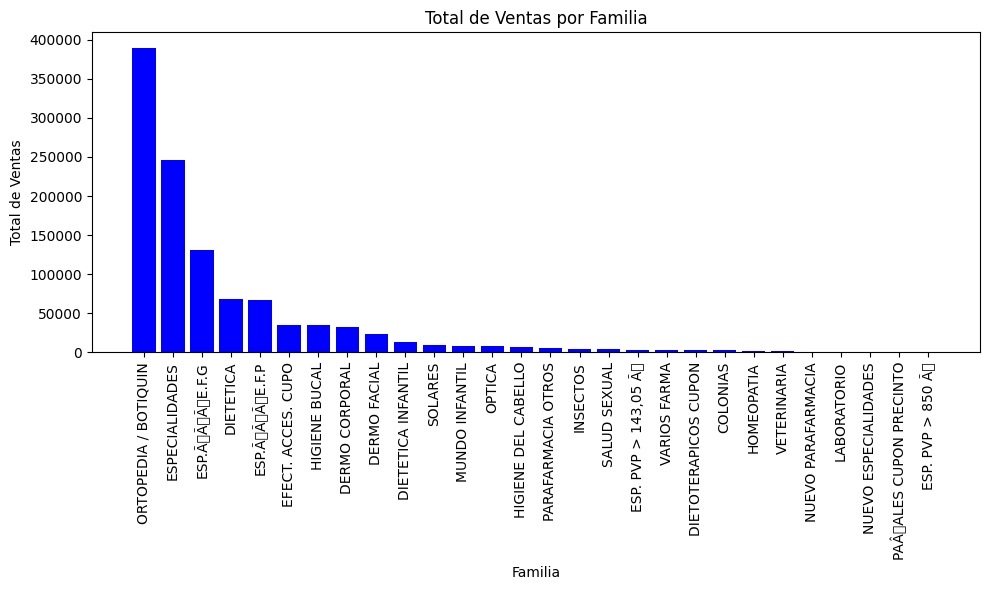

In [ ]:
ventas_por_familia = ventas.groupby('Familia')['Cantidad'].sum().reset_index()

ventas_por_familia = ventas_por_familia.sort_values(by='Cantidad', ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(ventas_por_familia['Familia'], ventas_por_familia['Cantidad'], color='blue')

plt.xticks(rotation=90)

plt.xlabel('Familia')
plt.ylabel('Total de Ventas')
plt.title('Total de Ventas por Familia')

plt.tight_layout()
plt.show()

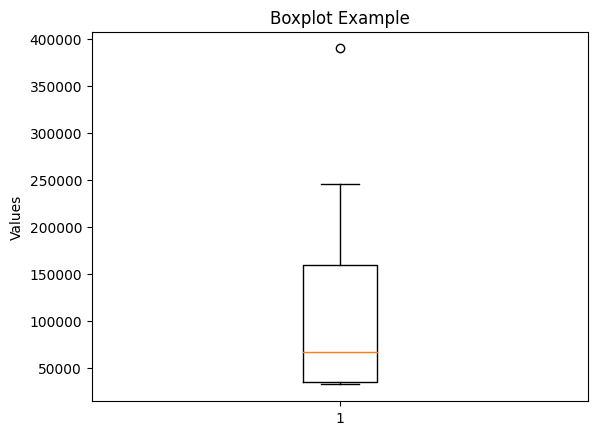

In [ ]:
plt.boxplot(ventas_por_familia.head(8)['Cantidad'])
plt.title('Boxplot Example')
plt.ylabel('Values')
plt.show()


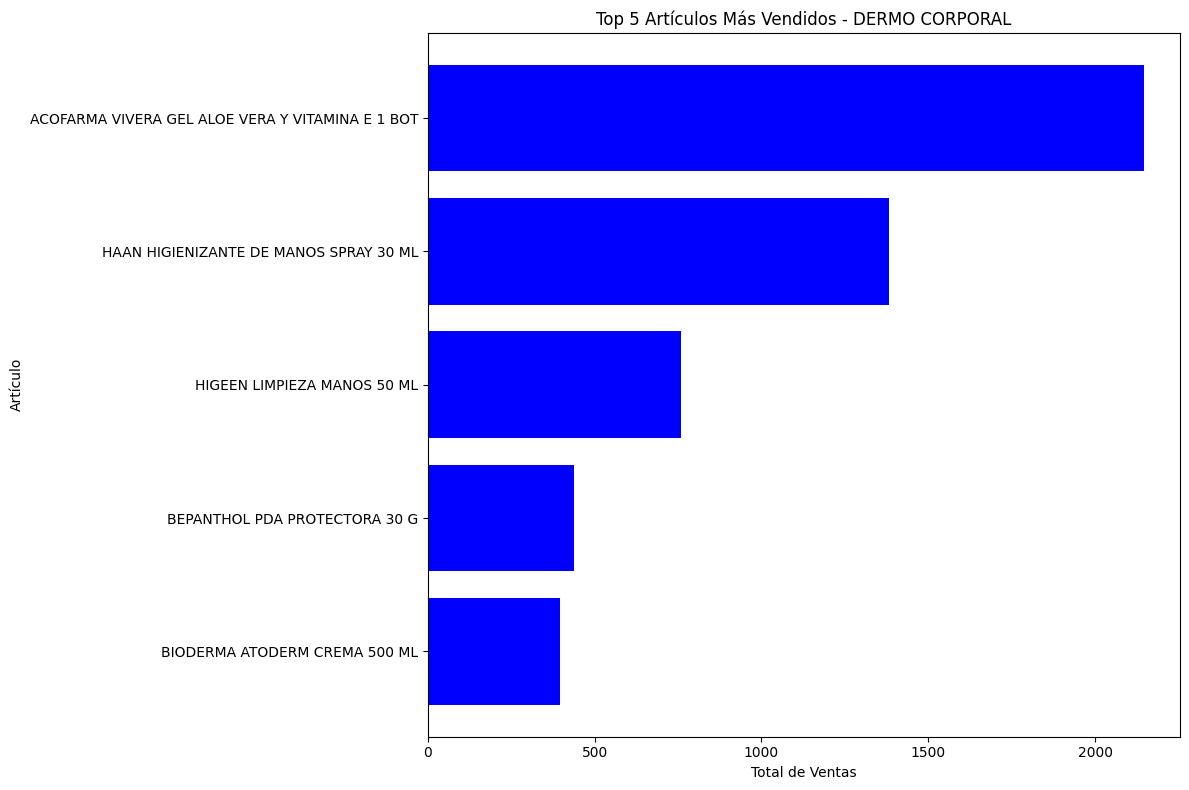

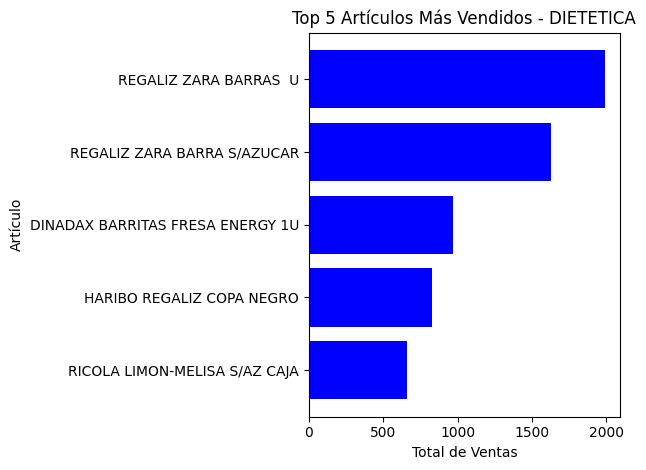

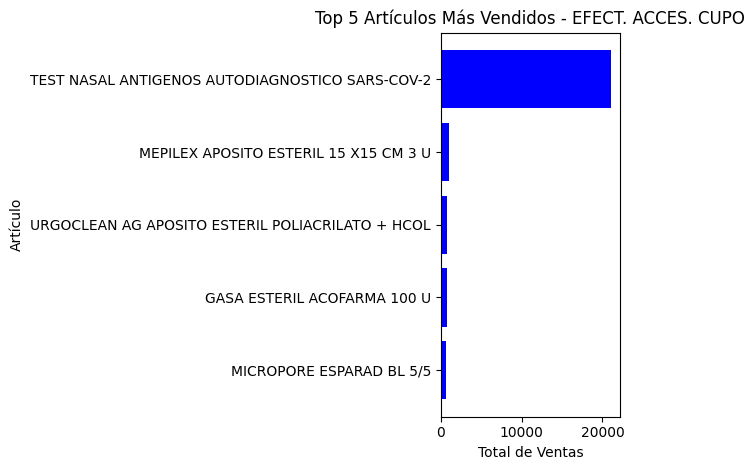

<ipython-input-24-f2184c342a81>:18: UserWarning: Glyph 138 (\x8a) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 138 (\x8a) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


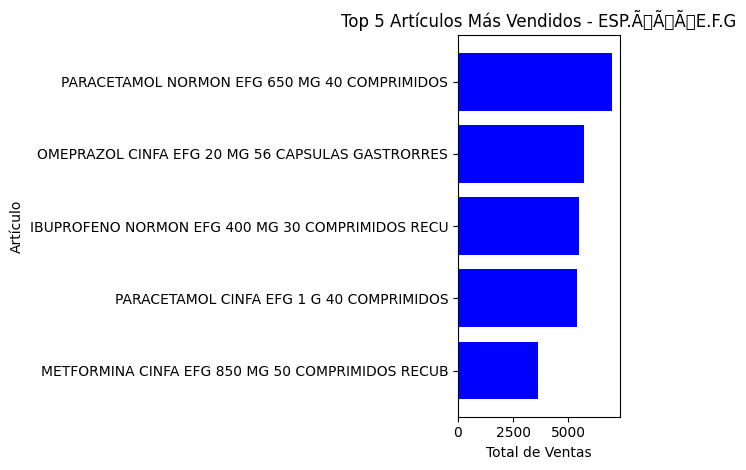

<ipython-input-24-f2184c342a81>:18: UserWarning: Glyph 138 (\x8a) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 138 (\x8a) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


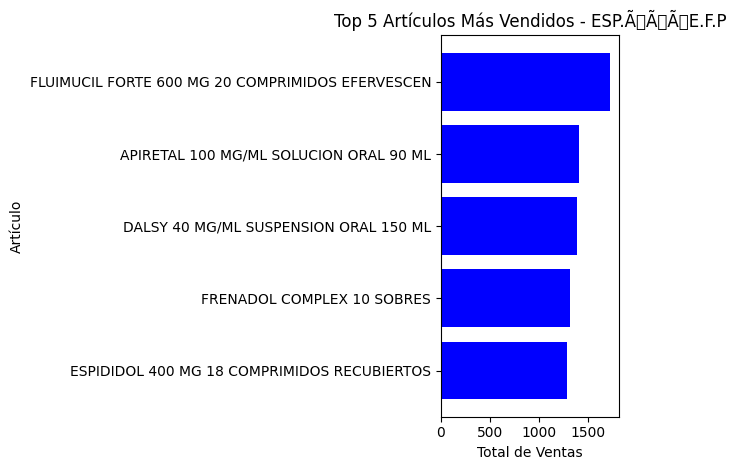

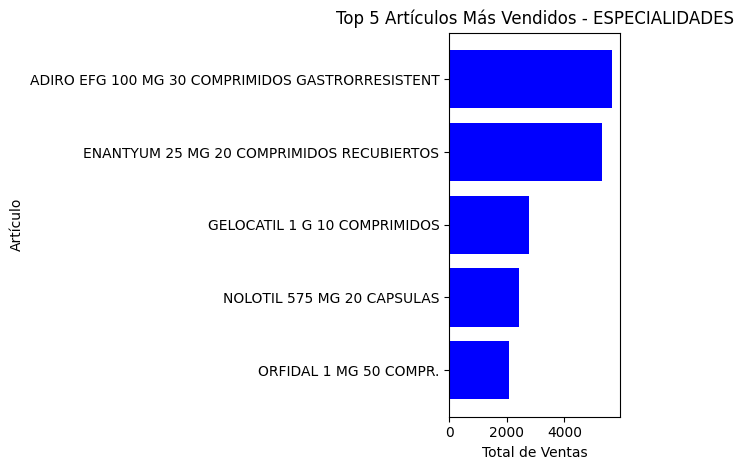

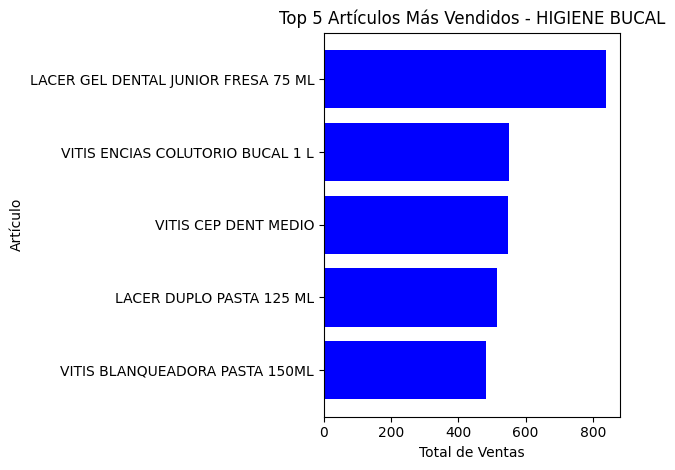

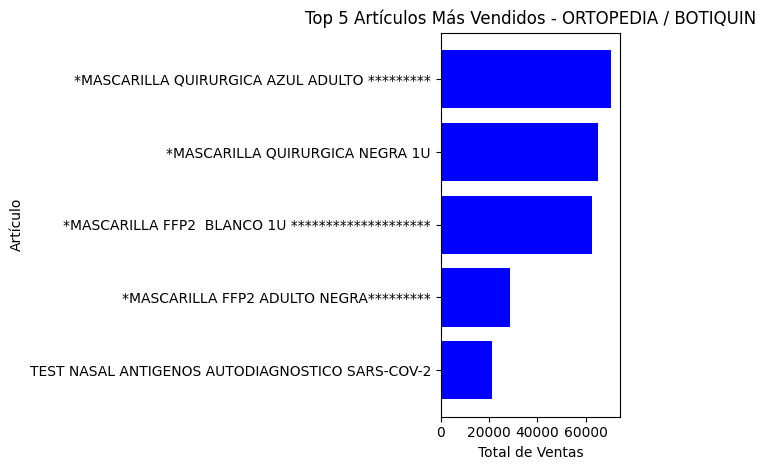

In [ ]:
top_8_familias = ventas_por_familia.head(8)['Familia']

top_8_data = ventas[ventas['Familia'].isin(top_8_familias)]

plt.figure(figsize=(12, 8))

for familia, data in top_8_data.groupby('Familia'):
    top_5_articulos = data.groupby('Descripcion')['Cantidad'].sum().nlargest(5)
    plt.barh(top_5_articulos.index, top_5_articulos.values, color='blue')
    plt.xlabel('Total de Ventas')
    plt.ylabel('Artículo')
    plt.title(f'Top 5 Artículos Más Vendidos - {familia}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [ ]:
top_5_por_familia = []

for familia, data in top_8_data.groupby('Familia'):
    top_5_articulos = data.groupby(['IdArticu', 'Descripcion'])['Cantidad'].sum().nlargest(5)
    top_5_ids_descripcion = [(id_articulo, descripcion) for id_articulo, descripcion in top_5_articulos.index]
    top_5_por_familia.append((familia, top_5_ids_descripcion))

for familia, top_5_ids_descripcion in top_5_por_familia:
    print(f"-----------------------")
    print(f"Familia: {familia}")
    for i, (id_articulo, descripcion) in enumerate(top_5_ids_descripcion, 1):
        print(f"{id_articulo} - {descripcion}")


-----------------------
Familia: DERMO CORPORAL
201811 - ACOFARMA VIVERA GEL ALOE VERA Y VITAMINA E 1 BOT
38528 - HAAN HIGIENIZANTE DE MANOS SPRAY 30 ML
195774 - HIGEEN LIMPIEZA MANOS 50 ML
347765 - BEPANTHOL PDA PROTECTORA 30 G
167925 - BIODERMA ATODERM CREMA 500 ML
-----------------------
Familia: DIETETICA
108365 - REGALIZ ZARA BARRAS  U
349 - REGALIZ ZARA BARRA S/AZUCAR
221484 - DINADAX BARRITAS FRESA ENERGY 1U
40132 - HARIBO REGALIZ COPA NEGRO
173398 - RICOLA LIMON-MELISA S/AZ CAJA
-----------------------
Familia: EFECT. ACCES. CUPO
207581 - TEST NASAL ANTIGENOS AUTODIAGNOSTICO SARS-COV-2
486910 - MEPILEX APOSITO ESTERIL 15 X15 CM 3 U
483289 - GASA ESTERIL ACOFARMA 100 U
410555 - MICROPORE ESPARAD BL 5/5
483263 - GASA ESTERIL ACOFARMA 25 U
-----------------------
Familia: ESP.ÃÃÃE.F.G
658247 - PARACETAMOL NORMON EFG 650 MG 40 COMPRIMIDOS
709818 - OMEPRAZOL CINFA EFG 20 MG 56 CAPSULAS GASTRORRES
754267 - IBUPROFENO NORMON EFG 400 MG 30 COMPRIMIDOS RECU
662026 - PARACETAMOL CINFA

# FILTRAR ARTICULOS

##FRENADOL

In [ ]:
ventas_filtro2 = ventas[ventas['Descripcion'].str.contains('FRENADOL')]
ventas_filtro2['Descripcion'] = 'FRENADOL'
ventas_filtro2

<ipython-input-26-21fafa7cdecf>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro2['Descripcion'] = 'FRENADOL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 10:16:50.253,1278624,1,10.45,760017,FRENADOL,278.0,2023-09-06,2025-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 12:06:36.573,1278662,1,10.45,965012,FRENADOL,69.0,2023-09-06,2024-12-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 12:27:13.360,1278669,1,10.45,760017,FRENADOL,278.0,2023-09-06,2025-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 12:44:18.577,1278685,1,10.45,681817,FRENADOL,26.0,2023-09-06,2025-08-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 14:34:27.127,1278757,1,10.45,760017,FRENADOL,278.0,2023-09-06,2025-05-01,22.0,ESP.ÃÃÃE.F.P
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 10:38:12.387,1583762,1,10.45,705657,FRENADOL,24.0,2023-06-07,2025-01-01,22.0,ESP.ÃÃÃE.F.P
2022-03-27 14:33:55.920,1583923,1,10.45,965012,FRENADOL,69.0,2023-09-06,2024-12-01,22.0,ESP.ÃÃÃE.F.P
2022-03-27 16:33:37.947,1583961,1,10.45,760017,FRENADOL,278.0,2023-09-06,2025-05-01,22.0,ESP.ÃÃÃE.F.P


##ESPIDIDOL

In [ ]:
ventas_filtro3 = ventas[ventas['Descripcion'].str.contains('ESPIDIDOL', case=False, na=False)]
ventas_filtro3['Descripcion'] = 'ESPIDIDOL'
ventas_filtro3

<ipython-input-27-c4f0be2e6105>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro3['Descripcion'] = 'ESPIDIDOL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2021-04-06 14:23:45.797,1443766,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
2021-04-06 14:23:45.797,1443766,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
2021-04-06 14:49:31.097,1443779,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
2021-04-07 09:14:02.607,1443995,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
2021-04-07 11:42:16.723,1444061,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
...,...,...,...,...,...,...,...,...,...,...
2022-03-25 11:38:52.633,1583104,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
2022-03-25 19:16:58.293,1583316,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
2022-03-26 16:05:40.573,1583591,1,5.95,677465,ESPIDIDOL,55.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P


##ENANTYUM

In [ ]:
ventas_filtro4 = ventas[ventas['Descripcion'].str.contains('ENANTYUM', case=False, na=False)]
ventas_filtro4['Descripcion'] = 'ENANTYUM'
ventas_filtro4

<ipython-input-28-c19a83eb5271>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro4['Descripcion'] = 'ENANTYUM'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 11:42:04.387,1278653,1,4,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES
2020-01-01 11:42:04.387,1278653,1,4,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES
2020-01-01 13:04:11.627,1278696,1,4,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES
2020-01-01 13:35:50.157,1278716,1,4,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES
2020-01-01 13:35:50.157,1278716,1,4,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 18:31:53.970,1584022,1,4.0,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES
2022-03-27 18:41:54.803,1584028,1,4.0,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES
2022-03-27 18:44:42.497,1584031,1,4.0,681957,ENANTYUM,101.0,2023-11-06,2024-09-30,2.0,ESPECIALIDADES


##GELOCATIL

In [ ]:
ventas_filtro5 = ventas[ventas['Descripcion'].str.contains('GELOCATIL', case=False, na=False)]
ventas_filtro5['Descripcion'] = 'GELOCATIL'
ventas_filtro5

<ipython-input-29-e938f6a9cbd2>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro5['Descripcion'] = 'GELOCATIL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 14:07:26.337,1278736,1,3.9,715240,GELOCATIL,192.0,2023-11-09,2024-05-01,2.0,ESPECIALIDADES
2020-01-01 14:09:50.773,1278739,1,3.9,715240,GELOCATIL,192.0,2023-11-09,2024-05-01,2.0,ESPECIALIDADES
2020-01-01 16:36:46.840,1278804,1,3.9,715240,GELOCATIL,192.0,2023-11-09,2024-05-01,2.0,ESPECIALIDADES
2020-01-01 17:13:03.783,1278827,1,3.9,715240,GELOCATIL,192.0,2023-11-09,2024-05-01,2.0,ESPECIALIDADES
2020-01-01 19:36:29.120,1278920,1,3.9,715240,GELOCATIL,192.0,2023-11-09,2024-05-01,2.0,ESPECIALIDADES
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 13:30:03.220,1583882,2,5.95,715242,GELOCATIL,86.0,2023-11-09,2025-10-01,2.0,ESPECIALIDADES
2022-03-27 13:46:09.397,1583890,1,5.95,715242,GELOCATIL,86.0,2023-11-09,2025-10-01,2.0,ESPECIALIDADES
2022-03-27 16:19:13.167,1583958,1,4.2,715240,GELOCATIL,192.0,2023-11-09,2024-05-01,2.0,ESPECIALIDADES


##NOLOTIL

In [ ]:
ventas_filtro6 = ventas[ventas['Descripcion'].str.contains('NOLOTIL', case=False, na=False)]
ventas_filtro6['Descripcion'] = 'NOLOTIL'
ventas_filtro6

<ipython-input-30-7dc3c03aa4e1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro6['Descripcion'] = 'NOLOTIL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 10:30:40.733,1278626,1,2.26,729566,NOLOTIL,104.0,2023-11-08,2024-01-31,2.0,ESPECIALIDADES
2020-01-01 17:02:43.130,1278820,1,3.89,729061,NOLOTIL,2.0,2023-11-16,2025-09-30,2.0,ESPECIALIDADES
2020-01-02 16:20:25.153,1279259,1,2.26,729566,NOLOTIL,104.0,2023-11-08,2024-01-31,2.0,ESPECIALIDADES
2020-01-03 15:41:54.880,1279632,1,2.26,729566,NOLOTIL,104.0,2023-11-08,2024-01-31,2.0,ESPECIALIDADES
2020-01-03 16:01:18.923,1279640,1,2.26,729566,NOLOTIL,104.0,2023-11-08,2024-01-31,2.0,ESPECIALIDADES
...,...,...,...,...,...,...,...,...,...,...
2022-03-24 18:47:07.757,1582918,1,2.26,729566,NOLOTIL,104.0,2023-11-08,2024-01-31,2.0,ESPECIALIDADES
2022-03-25 10:20:25.733,1583057,1,2.26,729566,NOLOTIL,104.0,2023-11-08,2024-01-31,2.0,ESPECIALIDADES
2022-03-25 13:03:51.533,1583149,1,2.26,729566,NOLOTIL,104.0,2023-11-08,2024-01-31,2.0,ESPECIALIDADES


##ORFIDAL

In [ ]:
ventas_filtro7 = ventas[ventas['Descripcion'].str.contains('ORFIDAL', case=False, na=False)]
ventas_filtro7['Descripcion'] = 'ORFIDAL'
ventas_filtro7

<ipython-input-31-7bc710d5449a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro7['Descripcion'] = 'ORFIDAL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 08:29:43.410,1278615,2,1.72,770065,ORFIDAL,10.0,2023-11-20,2024-09-30,2.0,ESPECIALIDADES
2020-01-01 10:09:17.547,1278622,2,1.72,770065,ORFIDAL,10.0,2023-11-20,2024-09-30,2.0,ESPECIALIDADES
2020-01-01 19:15:35.993,1278906,1,1.72,770065,ORFIDAL,10.0,2023-11-20,2024-09-30,2.0,ESPECIALIDADES
2020-01-02 09:18:17.607,1279032,1,1.37,770057,ORFIDAL,3.0,2023-11-15,2024-06-30,2.0,ESPECIALIDADES
2020-01-02 09:18:17.607,1279032,1,1.37,770057,ORFIDAL,3.0,2023-11-15,2024-06-30,2.0,ESPECIALIDADES
...,...,...,...,...,...,...,...,...,...,...
2022-03-25 12:11:31.170,1583124,1,1.72,770065,ORFIDAL,10.0,2023-11-20,2024-09-30,2.0,ESPECIALIDADES
2022-03-26 13:22:16.887,1583519,1,1.72,770065,ORFIDAL,10.0,2023-11-20,2024-09-30,2.0,ESPECIALIDADES
2022-03-26 19:45:12.687,1583683,1,1.37,770057,ORFIDAL,3.0,2023-11-15,2024-06-30,2.0,ESPECIALIDADES


##DALSY

In [ ]:
ventas_filtro8 = ventas[ventas['Descripcion'].str.contains('DALSY', case=False, na=False)]
ventas_filtro8['Descripcion'] = 'DALSY'
ventas_filtro8

<ipython-input-32-b2a163785277>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro8['Descripcion'] = 'DALSY'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 17:56:41.903,1278854,1,7.45,666107,DALSY,75.0,2023-09-18,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 18:26:49.783,1278873,1,7.45,666107,DALSY,75.0,2023-09-18,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 20:03:18.527,1278944,1,7.45,666107,DALSY,75.0,2023-09-18,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-02 10:17:44.717,1279056,1,5.95,660782,DALSY,288.0,2023-09-18,2024-06-01,22.0,ESP.ÃÃÃE.F.P
2020-01-02 18:27:06.963,1279328,1,7.45,666107,DALSY,75.0,2023-09-18,2024-05-01,22.0,ESP.ÃÃÃE.F.P
...,...,...,...,...,...,...,...,...,...,...
2022-03-26 21:10:52.827,1583712,1,7.45,666107,DALSY,75.0,2023-09-18,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2022-03-27 11:06:52.110,1583778,1,7.45,666107,DALSY,75.0,2023-09-18,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2022-03-27 11:11:31.323,1583780,1,7.45,666107,DALSY,75.0,2023-09-18,2024-05-01,22.0,ESP.ÃÃÃE.F.P


##APIRETAL

In [ ]:
ventas_filtro9 = ventas[ventas['Descripcion'].str.contains('APIRETAL', case=False, na=False)]
ventas_filtro9['Descripcion'] = 'APIRETAL'
ventas_filtro9

<ipython-input-33-bc9f3aec8cb4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro9['Descripcion'] = 'APIRETAL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 13:21:42.900,1278703,1,1.75,750711,APIRETAL,155.0,2023-01-13,2024-10-01,2.0,ESPECIALIDADES
2020-01-01 14:16:55.963,1278741,1,3.12,750521,APIRETAL,153.0,2023-09-05,2024-05-01,2.0,ESPECIALIDADES
2020-01-01 14:48:15.097,1278764,1,5.5,661267,APIRETAL,242.0,2023-11-07,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 14:58:20.747,1278770,1,5.5,661267,APIRETAL,242.0,2023-11-07,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 18:45:41.900,1278884,1,1.75,750711,APIRETAL,155.0,2023-01-13,2024-10-01,2.0,ESPECIALIDADES
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 10:47:21.803,1583768,1,1.75,750711,APIRETAL,155.0,2023-01-13,2024-10-01,2.0,ESPECIALIDADES
2022-03-27 16:06:50.290,1583950,1,6.1,661267,APIRETAL,242.0,2023-11-07,2024-05-01,22.0,ESP.ÃÃÃE.F.P
2022-03-27 17:18:26.623,1583978,1,3.12,750521,APIRETAL,153.0,2023-09-05,2024-05-01,2.0,ESPECIALIDADES


##FLUIMUCIL

In [ ]:
ventas_filtro10 = ventas[ventas['Descripcion'].str.contains('FLUIMUCIL', case=False, na=False)]
ventas_filtro10['Descripcion'] = 'FLUIMUCIL'
ventas_filtro10

<ipython-input-34-218a13803540>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro10['Descripcion'] = 'FLUIMUCIL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 10:16:50.253,1278624,1,6.93,884403,FLUIMUCIL,15.0,2023-11-20,2026-02-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 11:29:40.563,1278642,1,6.93,884403,FLUIMUCIL,15.0,2023-11-20,2026-02-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 13:55:20.887,1278728,1,6.93,884403,FLUIMUCIL,15.0,2023-11-20,2026-02-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 14:17:12.227,1278742,1,6.93,884403,FLUIMUCIL,15.0,2023-11-20,2026-02-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 17:34:07.150,1278840,1,6.93,848531,FLUIMUCIL,11.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
...,...,...,...,...,...,...,...,...,...,...
2022-03-26 17:45:46.300,1583629,1,7.06,884403,FLUIMUCIL,15.0,2023-11-20,2026-02-01,22.0,ESP.ÃÃÃE.F.P
2022-03-26 20:31:48.283,1583701,1,7.06,848531,FLUIMUCIL,11.0,2023-10-03,2024-04-01,22.0,ESP.ÃÃÃE.F.P
2022-03-27 09:28:13.350,1583737,1,7.06,884403,FLUIMUCIL,15.0,2023-11-20,2026-02-01,22.0,ESP.ÃÃÃE.F.P


##IBUPROFENO

In [ ]:
ventas_filtro11 = ventas[ventas['Descripcion'].str.contains('IBUPROFENO', case=False, na=False)]
ventas_filtro11['Descripcion'] = 'IBUPROFENO'
ventas_filtro11

<ipython-input-35-eb862089415b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro11['Descripcion'] = 'IBUPROFENO'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 10:15:12.263,1278623,1,2.06,754267,IBUPROFENO,45.0,2023-08-24,2024-02-01,23.0,ESP.ÃÃÃE.F.G
2020-01-01 12:21:20.840,1278665,1,2.06,754267,IBUPROFENO,45.0,2023-08-24,2024-02-01,23.0,ESP.ÃÃÃE.F.G
2020-01-01 13:03:00.853,1278695,1,10.9,715140,IBUPROFENO,41.0,2023-09-25,2025-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 14:00:40.327,1278732,1,2.06,754267,IBUPROFENO,45.0,2023-08-24,2024-02-01,23.0,ESP.ÃÃÃE.F.G
2020-01-01 14:32:38.770,1278755,1,2.06,754267,IBUPROFENO,45.0,2023-08-24,2024-02-01,23.0,ESP.ÃÃÃE.F.G
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 17:04:09.467,1583973,1,1.97,754846,IBUPROFENO,49.0,2023-11-17,2024-02-01,23.0,ESP.ÃÃÃE.F.G
2022-03-27 18:11:19.437,1584006,1,1.97,754846,IBUPROFENO,49.0,2023-11-17,2024-02-01,23.0,ESP.ÃÃÃE.F.G
2022-03-27 18:31:53.970,1584022,1,1.97,754846,IBUPROFENO,49.0,2023-11-17,2024-02-01,23.0,ESP.ÃÃÃE.F.G


##PARACETAMOL

In [ ]:
ventas_filtro12 = ventas[ventas['Descripcion'].str.contains('PARACETAMOL', case=False, na=False)]
ventas_filtro12['Descripcion'] = 'PARACETAMOL'
ventas_filtro12

<ipython-input-36-d208fc78716f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro12['Descripcion'] = 'PARACETAMOL'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 10:30:40.733,1278626,1,1.31,658247,PARACETAMOL,55.0,2023-08-24,2027-06-01,23.0,ESP.ÃÃÃE.F.G
2020-01-01 11:38:09.627,1278649,1,1.9,662025,PARACETAMOL,63.0,2023-08-25,2025-11-30,23.0,ESP.ÃÃÃE.F.G
2020-01-01 11:39:37.523,1278650,1,1.31,658247,PARACETAMOL,55.0,2023-08-24,2027-06-01,23.0,ESP.ÃÃÃE.F.G
2020-01-01 14:22:02.490,1278747,1,1.31,658247,PARACETAMOL,55.0,2023-08-24,2027-06-01,23.0,ESP.ÃÃÃE.F.G
2020-01-01 16:16:14.840,1278795,1,1.9,662025,PARACETAMOL,63.0,2023-08-25,2025-11-30,23.0,ESP.ÃÃÃE.F.G
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 20:03:04.310,1584091,1,1.31,658247,PARACETAMOL,55.0,2023-08-24,2027-06-01,23.0,ESP.ÃÃÃE.F.G
2022-03-27 20:49:47.377,1584122,1,1.31,658247,PARACETAMOL,55.0,2023-08-24,2027-06-01,23.0,ESP.ÃÃÃE.F.G
2022-03-27 21:15:22.723,1584135,1,2.5,662026,PARACETAMOL,74.0,2023-10-13,2024-03-31,23.0,ESP.ÃÃÃE.F.G


##TEST ANTIGENOS

In [ ]:
ventas_filtro13 = ventas[ventas['Descripcion'].str.contains('TEST NASAL|ANTIGENOS', case=False, na=False)]
ventas_filtro13['Descripcion'] = 'TEST ANTIGENOS'
ventas_filtro13

<ipython-input-37-dc816e0afb73>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro13['Descripcion'] = 'TEST ANTIGENOS'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2021-07-20 12:17:21.213,1482959,2,34.75,204410,TEST ANTIGENOS,3.0,2022-01-17,NaN,13.0,ORTOPEDIA / BOTIQUIN
2021-07-22 10:14:16.697,1483671,3,34.75,204410,TEST ANTIGENOS,3.0,2022-01-17,NaN,13.0,ORTOPEDIA / BOTIQUIN
2021-07-23 14:03:10.440,1484173,1,34.75,204410,TEST ANTIGENOS,3.0,2022-01-17,NaN,13.0,ORTOPEDIA / BOTIQUIN
2021-07-23 14:06:08.040,1484174,1,34.75,204410,TEST ANTIGENOS,3.0,2022-01-17,NaN,13.0,ORTOPEDIA / BOTIQUIN
2021-07-23 14:12:50.920,1484177,2,34.75,204410,TEST ANTIGENOS,3.0,2022-01-17,NaN,13.0,ORTOPEDIA / BOTIQUIN
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 18:43:45.460,1584030,1,2.94,112102,TEST ANTIGENOS,63.0,2023-09-16,2023-12-01,13.0,ORTOPEDIA / BOTIQUIN
2022-03-27 19:12:41.087,1584052,4,2.94,112102,TEST ANTIGENOS,63.0,2023-09-16,2023-12-01,13.0,ORTOPEDIA / BOTIQUIN
2022-03-27 19:18:24.843,1584059,1,2.94,112102,TEST ANTIGENOS,63.0,2023-09-16,2023-12-01,13.0,ORTOPEDIA / BOTIQUIN


##ALCOHOL DESINFECTANTE

In [ ]:
ventas_filtro14 = ventas[ventas['Descripcion'].str.contains('ALCOHOL.*96|ALCOHOL.*70|GEL HIDROAL|HIGEEN|HAAN HIGIENIZANTE', case=False, na=False)]
ventas_filtro14['Descripcion'] = 'ALCOHOL DESINFECTANTE'
ventas_filtro14

<ipython-input-38-1a99aac11156>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro14['Descripcion'] = 'ALCOHOL DESINFECTANTE'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 19:19:16.593,1278911,1,2.88,348565,ALCOHOL DESINFECTANTE,5.0,2023-11-15,2027-11-01,13.0,ORTOPEDIA / BOTIQUIN
2020-01-02 12:53:36.060,1279151,1,27.99,995191,ALCOHOL DESINFECTANTE,1.0,2023-08-25,NaN,22.0,ESP.ÃÃÃE.F.P
2020-01-02 13:09:09.130,1279164,1,5.9,38528,ALCOHOL DESINFECTANTE,0.0,2022-03-24,NaN,26.0,DERMO CORPORAL
2020-01-02 13:35:25.983,1279182,1,2.88,348565,ALCOHOL DESINFECTANTE,5.0,2023-11-15,2027-11-01,13.0,ORTOPEDIA / BOTIQUIN
2020-01-02 20:43:35.960,1279409,1,2.88,348565,ALCOHOL DESINFECTANTE,5.0,2023-11-15,2027-11-01,13.0,ORTOPEDIA / BOTIQUIN
...,...,...,...,...,...,...,...,...,...,...
2022-03-24 15:23:41.080,1582806,1,6.5,203635,ALCOHOL DESINFECTANTE,4.0,2023-05-02,2024-05-01,13.0,ORTOPEDIA / BOTIQUIN
2022-03-26 08:09:59.837,1583383,1,2.75,348565,ALCOHOL DESINFECTANTE,5.0,2023-11-15,2027-11-01,13.0,ORTOPEDIA / BOTIQUIN
2022-03-26 11:02:09.870,1583430,1,5.5,98769,ALCOHOL DESINFECTANTE,3.0,2022-10-11,2024-07-01,16.0,NUEVO PARAFARMACIA


##MASCARILLA

In [ ]:
ventas_filtro15 = ventas[ventas['Descripcion'].str.contains('MASCARILLAS AGON|MASCARILLAS OTM|MASCARILLA.*FF|MASCARILLA.*TRANSP|MASCARILLA QUIRU|MASCARILLA BLANCA|MASCARILLA PAPEL|MASCARILLA.*DES', case=False, na=False)]
ventas_filtro15['Descripcion'] = 'MASCARILLA'
ventas_filtro15

<ipython-input-39-2a81806172e8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_filtro15['Descripcion'] = 'MASCARILLA'


,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-02-08 11:01:09.680,1294548,1,10.84,165815,MASCARILLA,0.0,2020-02-23,NaN,NaN,NaN
2020-02-08 12:39:49.753,1294610,1,10.84,165815,MASCARILLA,0.0,2020-02-23,NaN,NaN,NaN
2020-02-11 11:33:55.240,1295928,15,0.25,5878,MASCARILLA,0.0,2020-02-11,NaN,NaN,NaN
2020-02-11 13:55:37.767,1296000,6,0.25,5878,MASCARILLA,0.0,2020-02-11,NaN,NaN,NaN
2020-02-11 14:44:35.237,1296024,5,0.25,5878,MASCARILLA,0.0,2020-02-11,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 20:10:29.883,1584096,1,1.5,1549,MASCARILLA,0.0,2023-03-12,NaN,13.0,ORTOPEDIA / BOTIQUIN
2022-03-27 20:23:33.323,1584107,10,1.5,54472,MASCARILLA,0.0,2023-01-30,NaN,13.0,ORTOPEDIA / BOTIQUIN
2022-03-27 21:09:30.277,1584132,24,0.59,67424,MASCARILLA,1.0,2023-09-25,NaN,13.0,ORTOPEDIA / BOTIQUIN


##DATAFRAME ARTICULOS SELECCIONADOS

In [ ]:
ventas_seleccionadas = pd.concat([ventas_filtro2, ventas_filtro3, ventas_filtro4, ventas_filtro5, ventas_filtro6, ventas_filtro7, ventas_filtro8, ventas_filtro9, ventas_filtro10, ventas_filtro11, ventas_filtro12, ventas_filtro13, ventas_filtro14, ventas_filtro15], ignore_index=False)
ventas_seleccionadas

,IdVenta,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,IdFamilia,Familia
FechaHora,,,,,,,,,,
2020-01-01 10:16:50.253,1278624,1,10.45,760017,FRENADOL,278.0,2023-09-06,2025-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 12:06:36.573,1278662,1,10.45,965012,FRENADOL,69.0,2023-09-06,2024-12-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 12:27:13.360,1278669,1,10.45,760017,FRENADOL,278.0,2023-09-06,2025-05-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 12:44:18.577,1278685,1,10.45,681817,FRENADOL,26.0,2023-09-06,2025-08-01,22.0,ESP.ÃÃÃE.F.P
2020-01-01 14:34:27.127,1278757,1,10.45,760017,FRENADOL,278.0,2023-09-06,2025-05-01,22.0,ESP.ÃÃÃE.F.P
...,...,...,...,...,...,...,...,...,...,...
2022-03-27 20:10:29.883,1584096,1,1.5,1549,MASCARILLA,0.0,2023-03-12,NaN,13.0,ORTOPEDIA / BOTIQUIN
2022-03-27 20:23:33.323,1584107,10,1.5,54472,MASCARILLA,0.0,2023-01-30,NaN,13.0,ORTOPEDIA / BOTIQUIN
2022-03-27 21:09:30.277,1584132,24,0.59,67424,MASCARILLA,1.0,2023-09-25,NaN,13.0,ORTOPEDIA / BOTIQUIN


#RECUPERADOS Y SUSCEPTIBLES

In [ ]:
casos_ib['num_recu'] = casos_ib['num_casos'].shift(10) - casos_ib['num_def']
casos_ib['num_recu'] = casos_ib['num_recu'].clip(lower=0)
casos_ib['num_recu'] = casos_ib['num_recu'].fillna(0)

poblacion_total = 959801
casos_ib['num_susc'] = poblacion_total - (casos_ib['num_casos'] + casos_ib['num_recu'] + casos_ib['num_def'])


In [ ]:
casos_ib

,num_casos,num_hosp,num_uci,num_def,num_recu,num_susc
fecha,,,,,,
2020-01-01,0,0,0,0,0.0,959801.0
2020-01-02,0,0,0,0,0.0,959801.0
2020-01-03,0,0,0,0,0.0,959801.0
2020-01-04,0,0,0,0,0.0,959801.0
2020-01-05,0,0,0,0,0.0,959801.0
...,...,...,...,...,...,...
2022-03-23,574,3,1,1,334.0,958892.0
2022-03-24,470,2,0,0,613.0,958718.0
2022-03-25,407,3,0,0,610.0,958784.0


#COMPARACION 2 ENTRE LAS BBDD

In [ ]:
ventas_diarias2 = ventas_seleccionadas.resample('D')['Cantidad'].sum()

ventas_diarias2 = ventas_diarias2.to_frame(name='VentasDiarias')
ventas_diarias2

,VentasDiarias
FechaHora,
2020-01-01,76
2020-01-02,92
2020-01-03,72
2020-01-04,80
2020-01-05,90
...,...
2022-03-23,427
2022-03-24,601
2022-03-25,941


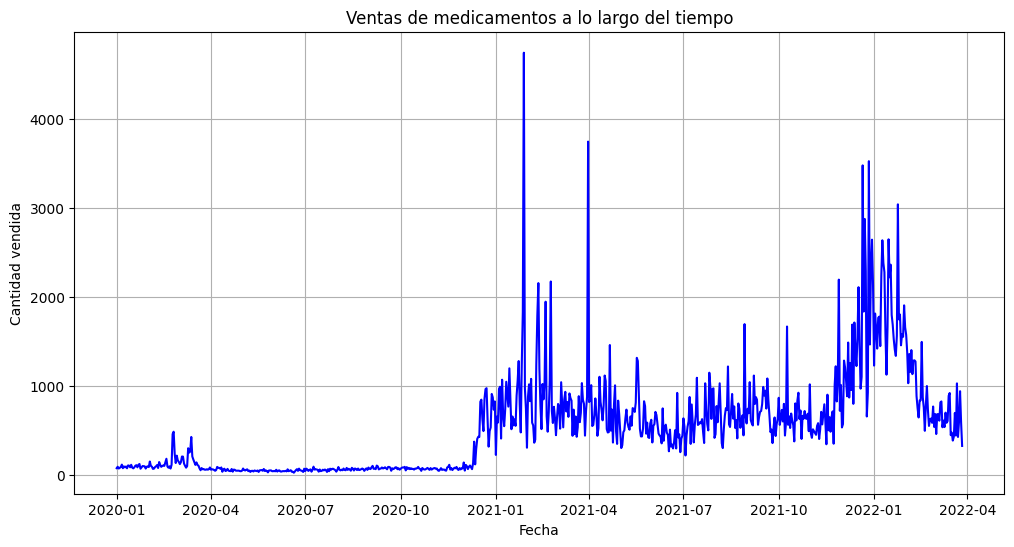

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ventas_diarias2.index, ventas_diarias2['VentasDiarias'], color='blue')
plt.title('Ventas de medicamentos a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad vendida')
plt.grid(True)
plt.show()

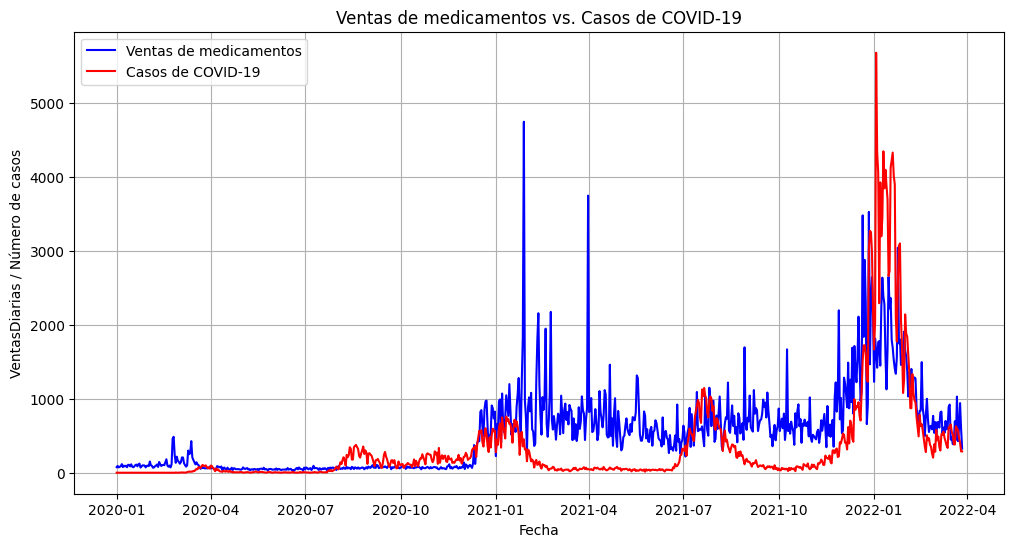

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ventas_diarias2.index, ventas_diarias2['VentasDiarias'], color='blue', label='Ventas de medicamentos')
plt.plot(casos_ib.index, casos_ib['num_casos'], color='red', label='Casos de COVID-19')
plt.title('Ventas de medicamentos vs. Casos de COVID-19')
plt.xlabel('Fecha')
plt.ylabel('VentasDiarias / Número de casos')
plt.legend()
plt.grid(True)
plt.show()

#VENTAS DIARIAS POR MEDICAMENTOS

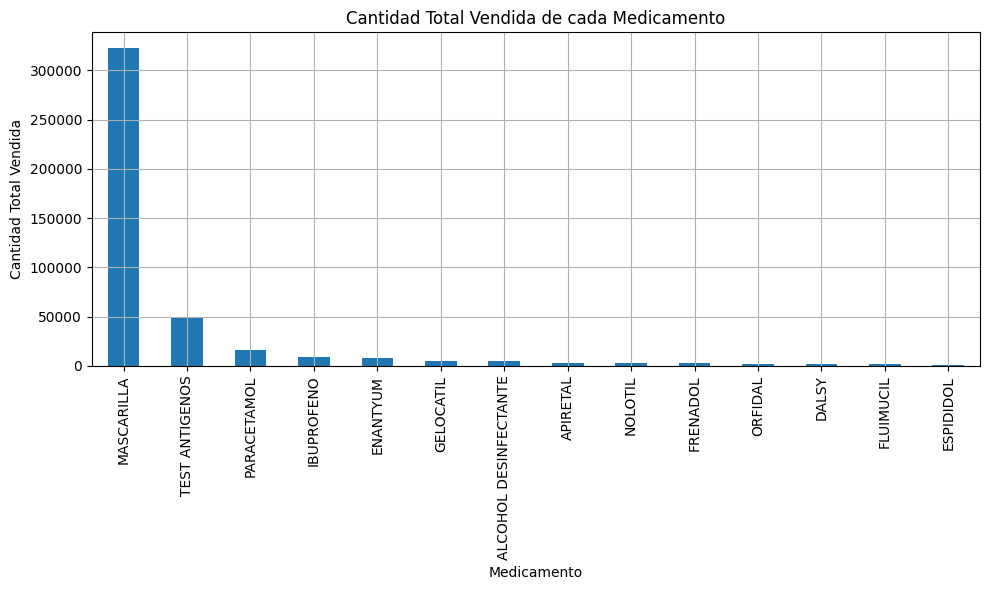

Resumen de Ventas de cada Medicamento:
                          sum       mean   max  min
Descripcion                                        
ALCOHOL DESINFECTANTE    4818   1.250130    29    0
APIRETAL                 2768   1.017647     6    0
DALSY                    2051   1.016353     6    0
ENANTYUM                 7601   1.054669     5    0
ESPIDIDOL                1286   1.087067    70    0
FLUIMUCIL                2043   1.046083    15    0
FRENADOL                 2512   1.029930     5    0
GELOCATIL                4985   1.082519    12    0
IBUPROFENO               9038   1.026579    20    0
MASCARILLA             322344  15.282761  1600    0
NOLOTIL                  2631   1.039100     5    0
ORFIDAL                  2285   1.099615     3    0
PARACETAMOL             16390   1.055581    11    0
TEST ANTIGENOS          48928   2.835091   400    0


In [ ]:

ventas_seleccionadas.index = pd.to_datetime(ventas_seleccionadas.index)

resumen_ventas_medicamentos = ventas_seleccionadas.groupby('Descripcion')['Cantidad'].agg(['sum', 'mean', 'max', 'min'])


plt.figure(figsize=(10, 6))
resumen_ventas_medicamentos['sum'].sort_values(ascending=False).plot(kind='bar')
plt.title('Cantidad Total Vendida de cada Medicamento')
plt.xlabel('Medicamento')
plt.ylabel('Cantidad Total Vendida')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Resumen de Ventas de cada Medicamento:")
print(resumen_ventas_medicamentos)


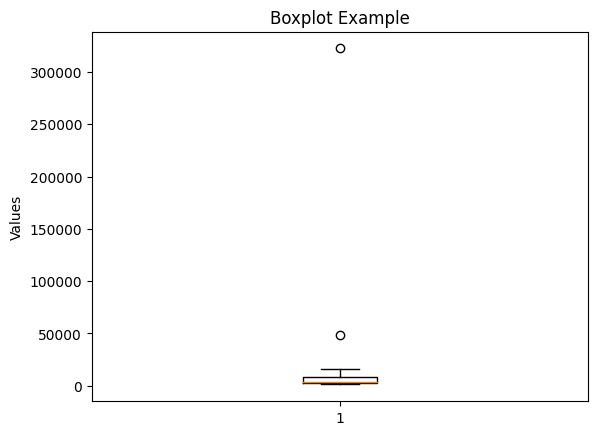

In [ ]:
plt.boxplot(resumen_ventas_medicamentos['sum'])
plt.title('Boxplot Example')
plt.ylabel('Values')
plt.show()

In [ ]:
ventas_diarias_por_medicamento = ventas_seleccionadas.groupby([pd.Grouper(freq='D'), 'Descripcion'])['Cantidad'].sum()

ventas_diarias_por_medicamento = ventas_diarias_por_medicamento.to_frame(name='VentasDiarias')

ventas_diarias_por_medicamento

VentasDiarias
FechaHora  Descripcion                         
2020-01-01 ALCOHOL DESINFECTANTE              1
           APIRETAL                           7
           DALSY                              3
           ENANTYUM                          12
           FLUIMUCIL                          8
...                                         ...
2022-03-27 MASCARILLA                       165
           NOLOTIL                            1
           ORFIDAL                            2
           PARACETAMOL                       33
           TEST ANTIGENOS                    78

[9368 rows x 1 columns]

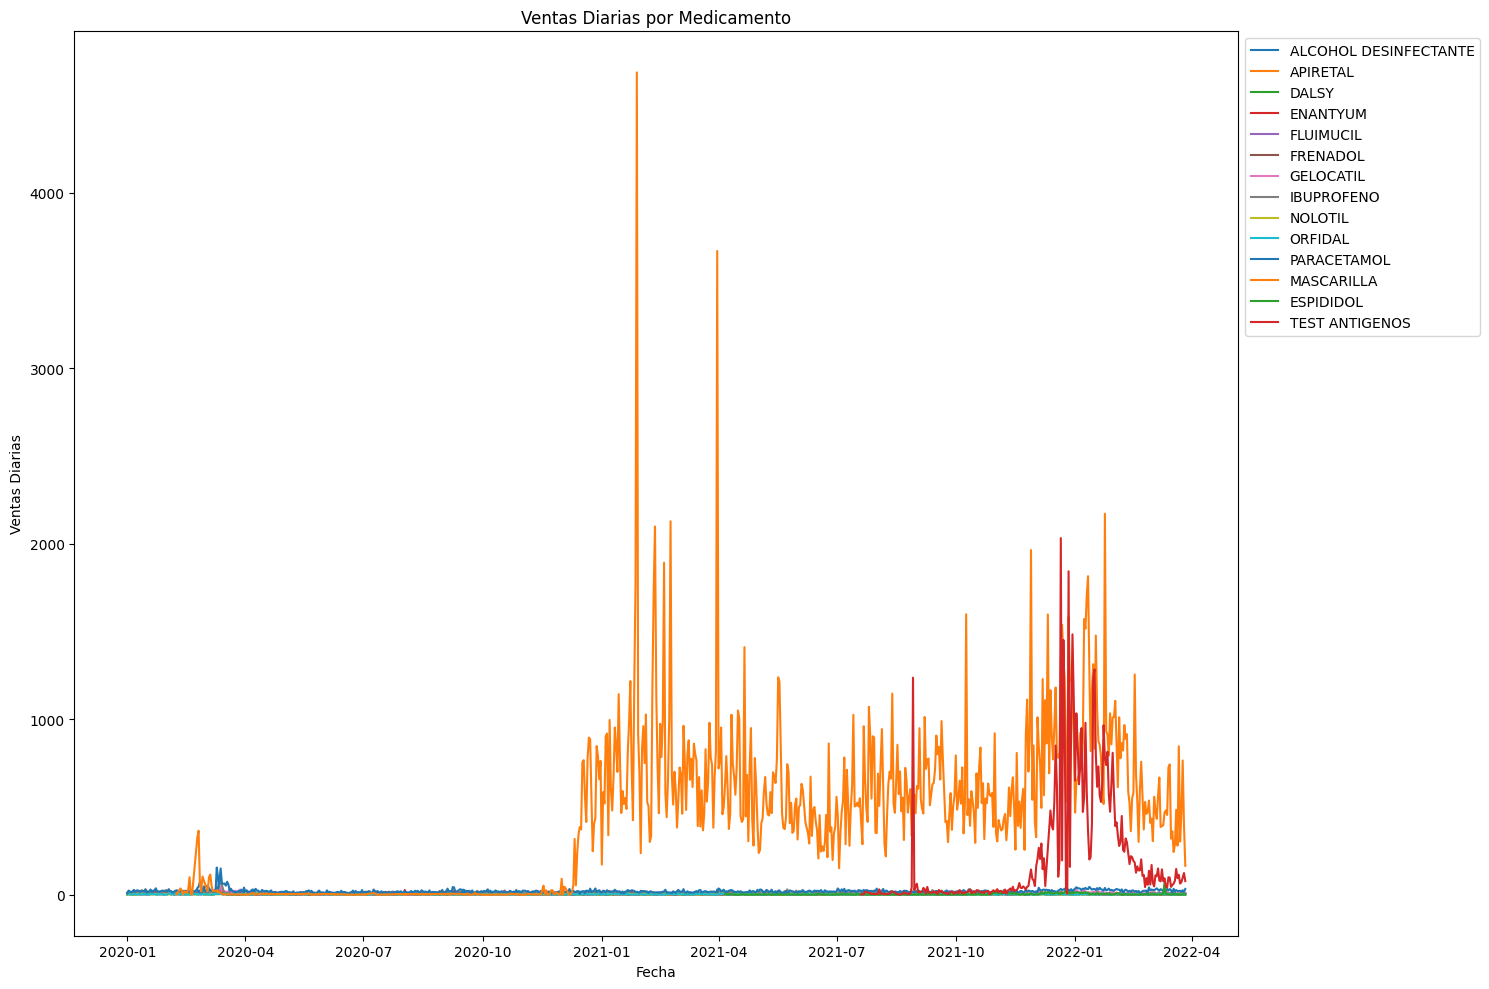

In [ ]:
medicamentos = ventas_diarias_por_medicamento.index.get_level_values('Descripcion').unique()

plt.figure(figsize=(15, 10))

for medicamento in medicamentos:
    datos_medicamento = ventas_diarias_por_medicamento.xs(medicamento, level='Descripcion')
    plt.plot(datos_medicamento.index, datos_medicamento['VentasDiarias'], label=medicamento)

plt.xlabel('Fecha')
plt.ylabel('Ventas Diarias')
plt.title('Ventas Diarias por Medicamento')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


Excluimos el grupo "MASCARILLA" y "TEST ANTIGENOS" para ver mejor el resto de grupos

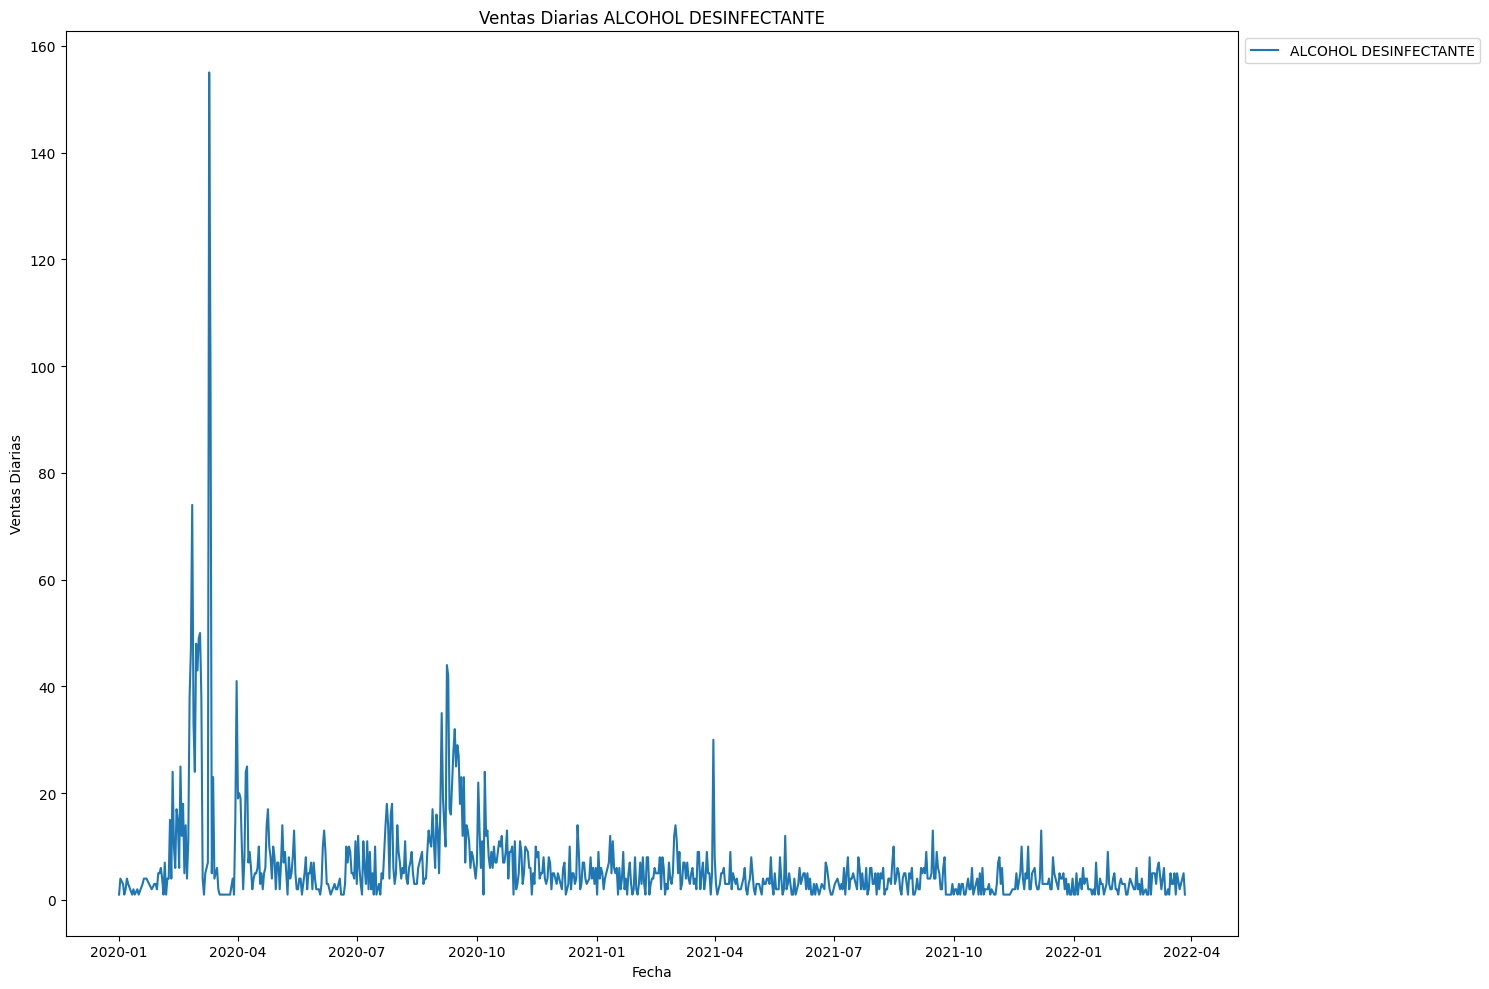

In [ ]:
ventas_diarias_por_medicamento2 = ventas_diarias_por_medicamento[ventas_diarias_por_medicamento.index.get_level_values('Descripcion')=='ALCOHOL DESINFECTANTE']

medicamentos = ventas_diarias_por_medicamento2.index.get_level_values('Descripcion').unique()

plt.figure(figsize=(15, 10))

for medicamento in medicamentos:
    datos_medicamento = ventas_diarias_por_medicamento2.xs(medicamento, level='Descripcion')
    plt.plot(datos_medicamento.index, datos_medicamento['VentasDiarias'], label=medicamento)

plt.xlabel('Fecha')
plt.ylabel('Ventas Diarias')
plt.title('Ventas Diarias ALCOHOL DESINFECTANTE')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

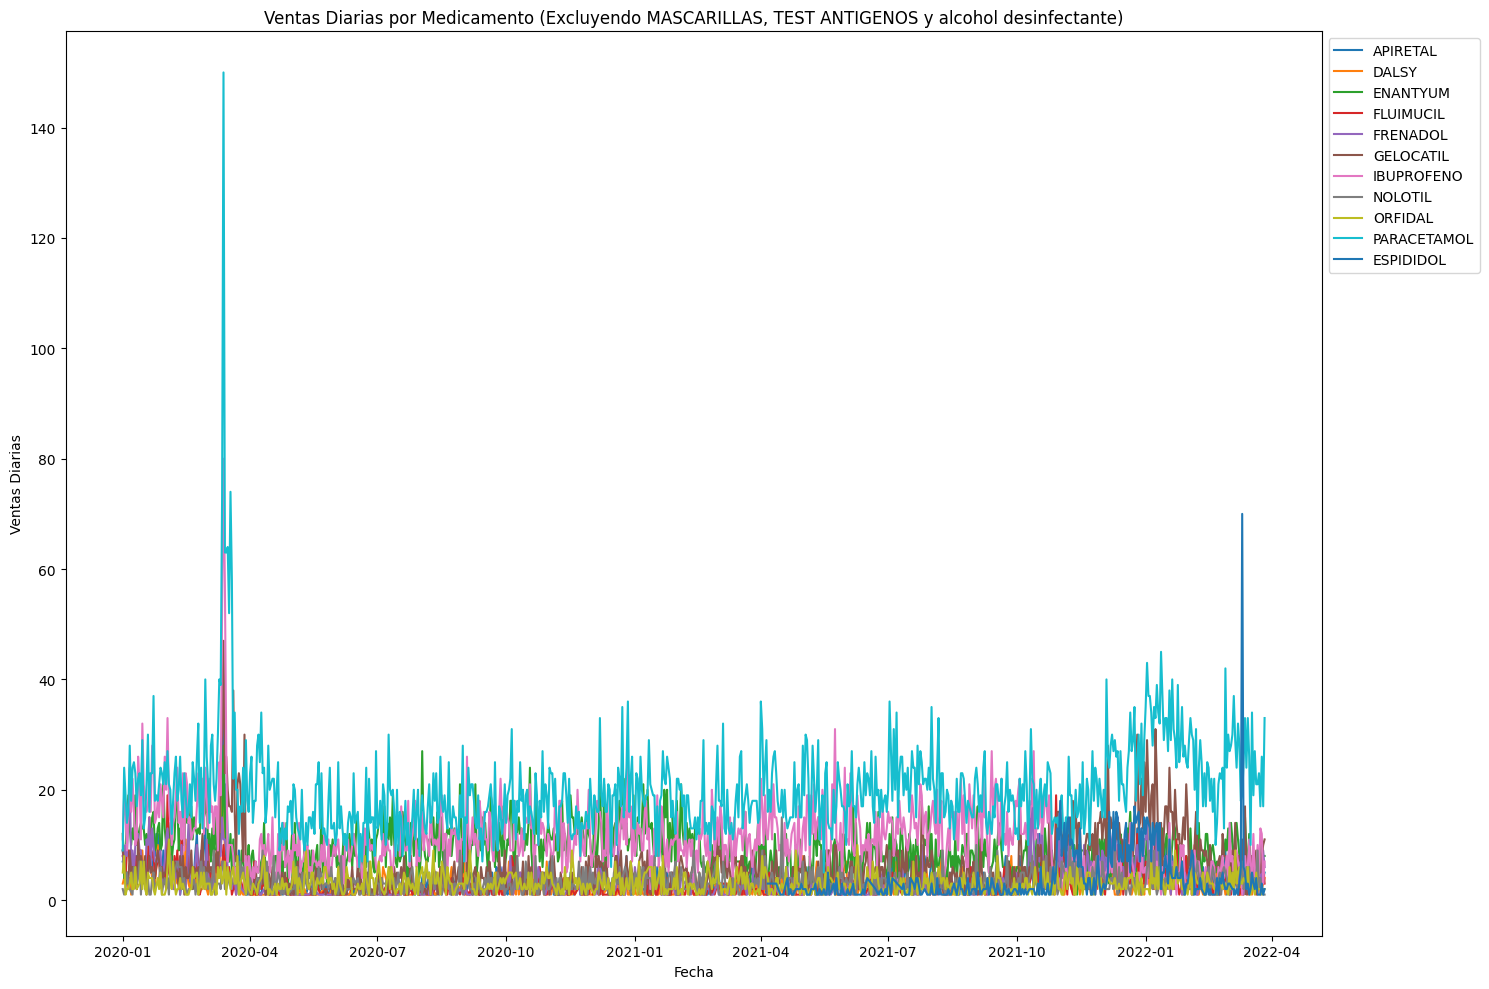

In [ ]:
ventas_diarias_por_medicamento2 = ventas_diarias_por_medicamento[~ventas_diarias_por_medicamento.index.get_level_values('Descripcion').isin(['MASCARILLA', 'TEST ANTIGENOS','ALCOHOL DESINFECTANTE'])]

medicamentos = ventas_diarias_por_medicamento2.index.get_level_values('Descripcion').unique()

plt.figure(figsize=(15, 10))

for medicamento in medicamentos:
    datos_medicamento = ventas_diarias_por_medicamento2.xs(medicamento, level='Descripcion')
    plt.plot(datos_medicamento.index, datos_medicamento['VentasDiarias'], label=medicamento)

plt.xlabel('Fecha')
plt.ylabel('Ventas Diarias')
plt.title('Ventas Diarias por Medicamento (Excluyendo MASCARILLAS, TEST ANTIGENOS y alcohol desinfectante)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#NUEVAS TASAS Y CORRELACION

In [ ]:

datos_combinados = pd.merge(casos_ib, ventas_diarias2, left_index=True, right_on='FechaHora', how='inner')

datos_combinados


,num_casos,num_hosp,num_uci,num_def,num_recu,num_susc,VentasDiarias
FechaHora,,,,,,,
2020-01-01,0,0,0,0,0.0,959801.0,76
2020-01-02,0,0,0,0,0.0,959801.0,92
2020-01-03,0,0,0,0,0.0,959801.0,72
2020-01-04,0,0,0,0,0.0,959801.0,80
2020-01-05,0,0,0,0,0.0,959801.0,90
...,...,...,...,...,...,...,...
2022-03-23,574,3,1,1,334.0,958892.0,427
2022-03-24,470,2,0,0,613.0,958718.0,601
2022-03-25,407,3,0,0,610.0,958784.0,941


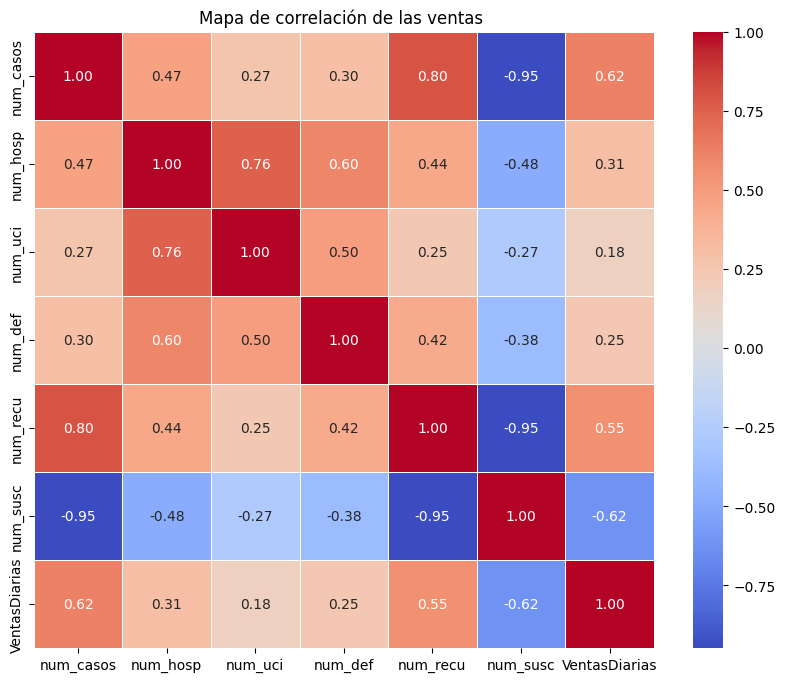

In [ ]:

datos_numericos = datos_combinados.select_dtypes(include=['float64', 'int64'])

correlation_matrix = datos_numericos.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de correlación de las ventas ')
plt.show()

In [ ]:
ventas_totales_diarias = ventas_diarias_por_medicamento.groupby(level=0)['VentasDiarias'].sum().rename('VentasTotalesDiarias')
ventas_diarias_por_medicamento = ventas_diarias_por_medicamento.reset_index().merge(ventas_totales_diarias, on='FechaHora').set_index(['FechaHora', 'Descripcion'])

datos_combinados_por_medicamento = pd.merge(casos_ib, ventas_diarias_por_medicamento, left_index=True, right_on='FechaHora', how='inner')

datos_combinados_por_medicamento_reset = datos_combinados_por_medicamento.reset_index()

datos_combinados_por_medicamento_reset['IdProducto'] = datos_combinados_por_medicamento_reset.groupby('Descripcion').ngroup() + 1

datos_combinados_por_medicamento = datos_combinados_por_medicamento_reset.set_index('FechaHora')

datos_combinados_por_medicamento


,Descripcion,num_casos,num_hosp,num_uci,num_def,num_recu,num_susc,VentasDiarias,VentasTotalesDiarias,IdProducto
FechaHora,,,,,,,,,,
2020-01-01,ALCOHOL DESINFECTANTE,0,0,0,0,0.0,959801.0,1,76,1
2020-01-01,APIRETAL,0,0,0,0,0.0,959801.0,7,76,2
2020-01-01,DALSY,0,0,0,0,0.0,959801.0,3,76,3
2020-01-01,ENANTYUM,0,0,0,0,0.0,959801.0,12,76,4
2020-01-01,FLUIMUCIL,0,0,0,0,0.0,959801.0,8,76,6
...,...,...,...,...,...,...,...,...,...,...
2022-03-27,MASCARILLA,288,6,0,2,551.0,958960.0,165,326,10
2022-03-27,NOLOTIL,288,6,0,2,551.0,958960.0,1,326,11
2022-03-27,ORFIDAL,288,6,0,2,551.0,958960.0,2,326,12


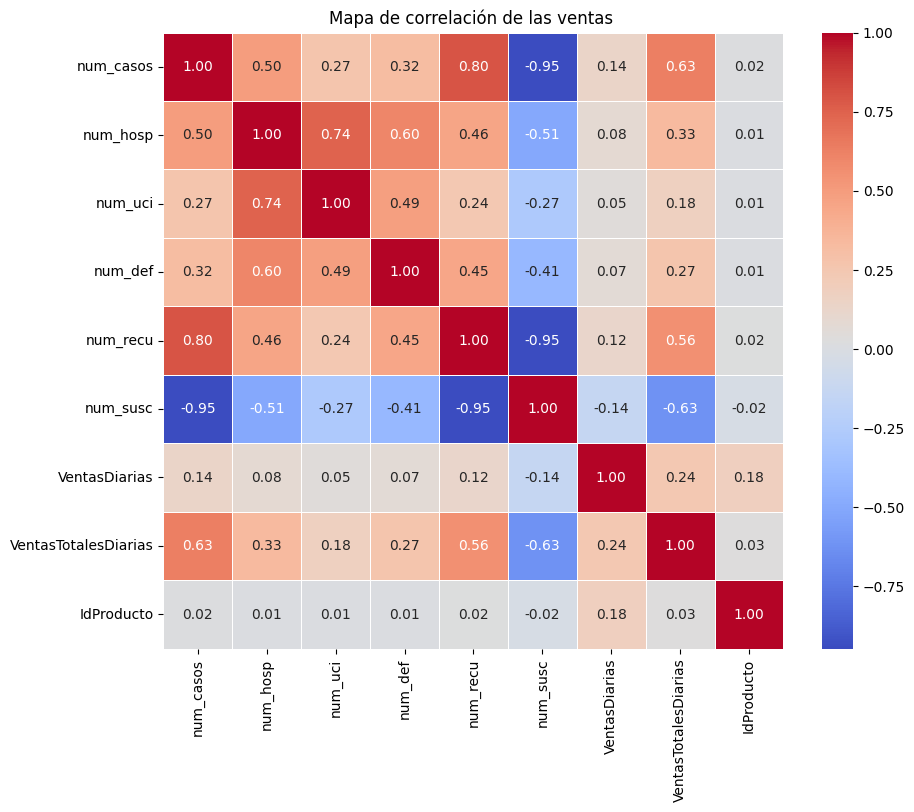

In [ ]:

datos_numericos = datos_combinados_por_medicamento.select_dtypes(include=['float64', 'int64'])

correlation_matrix = datos_numericos.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de correlación de las ventas ')
plt.show()

#EXPORTAR NUEVO DATAFRAME A CSV

In [ ]:
datos_combinados_por_medicamento.to_csv('datos_combinados_por_medicamento.csv', index=True)